# Recursive Sketch hyperparameter search across OpenML-CC18

This notebook estimates predictive performance by averaging held-out accuracy across a configurable set of OpenML-CC18 datasets and repeated stratified train/test splits. It then performs a deterministic random search over Recursive Sketch hyperparameters.

The search includes the representation mode (`fixed` or `expanding`), normalization, iteration count, adaptive embedding dimension (`dimension_ratio`), projection families, the internal path-estimator type and size, and the downstream `classifier`. The output format is fixed to sparse because it is a container choice, not a representation hyperparameter. Internal path estimators are a standard random forest or a bootstrapped recursive partition classifier with its default balanced linear SVM. Downstream choices are logistic regression, a standard 100-tree random forest, and an RBF SVM with automatic feature scaling and the default regularization convention. Each candidate is fitted independently on every dataset/repetition block. Dataset-level means are averaged so that each dataset contributes equally to the objective.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterSampler
from tqdm.auto import tqdm

from _hypothesis_utils import (
    DEFAULT_DIMENSION_RATIO,
    DEFAULT_N_ESTIMATORS,
    classification_score,
    forest_classifier,
    make_datasets,
    openml_classification_split,
    openml_output_classifier,
    timed_fit_transform,
)
from recursivesketch import RecursiveSketchClassifier
try:
    from recursive_partition import (
        BaggedRecursivePartitionClassifier,
        RecursivePartitionClassifier,
    )
except ModuleNotFoundError:
    search_roots = (Path.cwd(), *Path.cwd().parents)
    sister_candidates = [
        root / 'RecursiveParitionClassifier' for root in search_roots
    ]
    sister_repository = next(
        (candidate for candidate in sister_candidates if (candidate / 'recursive_partition').exists()),
        None,
    )
    if sister_repository is None:
        raise ModuleNotFoundError(
            'Install the RecursiveParitionClassifier sister repository or place it next to recursivesketch.'
        )
    sys.path.insert(0, str(sister_repository))
    from recursive_partition import (
        BaggedRecursivePartitionClassifier,
        RecursivePartitionClassifier,
    )
DATASET_SEED = 4279
SEARCH_SEED = 177
OUTPUT_FORMAT = 'sparse'
DATASET_NAMES = ['kr-vs-kp', 'letter']
# Example: DATASET_NAMES = ['kr-vs-kp', 'letter', 'balance-scale', 'mfeat-factors', 'mfeat-fourier']


SMOKE_TEST = True
DATASET_COUNT = 3 if SMOKE_TEST else 8
MAX_DATASET_SIZE = 100 if SMOKE_TEST else 1000
REPETITIONS = tuple(range(5)) if SMOKE_TEST else tuple(range(10))
N_SEARCH_ITER = 5 if SMOKE_TEST else 100

DATASETS = make_datasets(
    n=None if DATASET_NAMES is not None else DATASET_COUNT,
    max_size=MAX_DATASET_SIZE,
    seed=DATASET_SEED,
    dataset_names=DATASET_NAMES,
)

dataset_summary = pd.DataFrame([
    {
        'dataset_id': dataset.dataset_id,
        'name': dataset.name,
        'n_original': dataset.n_original,
        'n_used': dataset.n_used,
        'n_features': len(dataset.feature_names),
    }
    for dataset in DATASETS
])
display(dataset_summary)

,dataset_id,name,n_original,n_used,n_features
0,3,kr-vs-kp,3196,100,36
1,6,letter,20000,100,16


In [2]:
# Prepare identical evaluation blocks for every random-search candidate.
evaluation_blocks = []
for dataset in DATASETS:
    for repetition_id in REPETITIONS:
        X_train, X_test, y_train, y_test, preprocessor = openml_classification_split(
            dataset, seed=repetition_id
        )
        evaluation_blocks.append({
            'dataset_id': dataset.dataset_id,
            'dataset': dataset.name,
            'repetition_id': repetition_id,
            'p_encoded': X_train.shape[1],
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
        })

print(
    f'{len(DATASETS)} datasets × {len(REPETITIONS)} repetitions = '
    f'{len(evaluation_blocks)} evaluation blocks'
)
pd.DataFrame(evaluation_blocks)[
    ['dataset_id', 'dataset', 'repetition_id', 'p_encoded']
].head()

2 datasets × 5 repetitions = 10 evaluation blocks


,dataset_id,dataset,repetition_id,p_encoded
0,3,kr-vs-kp,0,71
1,3,kr-vs-kp,1,71
2,3,kr-vs-kp,2,70
3,3,kr-vs-kp,3,69
4,3,kr-vs-kp,4,71


## Random-search space

`dimension_ratio` is resolved separately for each dataset from its encoded feature count `p`: for example, `0.5` means `ceil(0.5 × p)` and `20` means `20 × p`. `n_components` remains an absolute fallback but is not searched here. The `n_estimators` value controls the internal random-forest tree count or the number of bootstrap members of the recursive-partition path estimator, depending on `path_estimator`; the downstream classifier is a separate choice.

In [3]:
# Edit this dictionary to define the candidate values for the random search.
# RecursiveSketchClassifier parameters plus model choices; each list is its range.
PARAMETER_RANGES = {
    'n_estimators': [30, 100, 300],
    'n_iterations': [1, 2, 3, 4],
    'dimension_mode': ['fixed', 'expanding'],
    'normalization': ['none', 'l1', 'l2'],
    'dimension_ratio': [1, 10, 20, 30, 40],
    'initial_projection_type': ['sparse', 'gaussian', 'signed_hash'],
    'path_projection_type': ['sparse', 'gaussian', 'signed_hash'],
    'concat_projection_type': ['sparse', 'gaussian', 'signed_hash'],
    'classifier': ['logistic_regression', 'random_forest', 'svm_rbf_auto_lambda'],
    'path_estimator': ['random_forest', 'recursive_partition'],
}

sampled_parameters = list(
    ParameterSampler(
        PARAMETER_RANGES,
        n_iter=N_SEARCH_ITER,
        random_state=SEARCH_SEED,
    )
)
pd.DataFrame(sampled_parameters)

,path_projection_type,path_estimator,normalization,n_iterations,n_estimators,initial_projection_type,dimension_ratio,dimension_mode,concat_projection_type,classifier
0,gaussian,random_forest,l1,2,300,gaussian,40,fixed,signed_hash,random_forest
1,signed_hash,recursive_partition,l1,3,300,sparse,30,fixed,signed_hash,logistic_regression
2,sparse,random_forest,none,3,30,signed_hash,20,expanding,gaussian,random_forest
3,gaussian,recursive_partition,l2,4,300,gaussian,20,expanding,signed_hash,svm_rbf_auto_lambda
4,gaussian,random_forest,l1,3,300,gaussian,1,expanding,signed_hash,logistic_regression


In [4]:
def make_internal_path_estimator(params, seed):
    if params['path_estimator'] == 'random_forest':
        return forest_classifier(seed, n_estimators=params['n_estimators'])
    if params['path_estimator'] == 'recursive_partition':
        return BaggedRecursivePartitionClassifier(
            estimator=RecursivePartitionClassifier(),
            n_estimators=params['n_estimators'],
            n_jobs=-1,
            random_state=seed,
        )
    raise ValueError(f"Unknown path estimator: {params['path_estimator']}")

def make_search_estimator(params, seed):
    return RecursiveSketchClassifier(
        estimator=make_internal_path_estimator(params, seed),
        n_components=64,
        n_iterations=params['n_iterations'],
        dimension_ratio=params['dimension_ratio'],
        dimension_mode=params['dimension_mode'],
        output_format=OUTPUT_FORMAT,
        initial_projection_type=params['initial_projection_type'],
        path_projection_type=params['path_projection_type'],
        concat_projection_type=params['concat_projection_type'],
        normalization=params['normalization'],
        random_state=seed,
    )

search_rows = []
block_rows = []
progress_bar_format = '{desc}{percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]'
progress_description_width = '420px'
def aligned_tqdm(iterable, **kwargs):
    progress = tqdm(iterable, **kwargs)
    container = getattr(progress, 'container', None)
    if container is not None:
        description = container.children[0]
        description.layout.width = progress_description_width
        description.layout.min_width = progress_description_width
        description.layout.flex = f'0 0 {progress_description_width}'
    return progress
for candidate_id, params in aligned_tqdm(
    enumerate(sampled_parameters), total=len(sampled_parameters),
    desc='Random-search candidates',
    bar_format=progress_bar_format,
):
    candidate_start = time.perf_counter()
    candidate_scores = []
    for block in aligned_tqdm(
        evaluation_blocks,
        desc='Candidate',
        bar_format=progress_bar_format,
        leave=False,
    ):
        # Derive independent but reproducible model seeds for each block.
        model_seed = SEARCH_SEED + candidate_id * 10000 + block['repetition_id']
        sketch = make_search_estimator(params, seed=model_seed)
        X_train_view, fit_wall, fit_cpu = timed_fit_transform(
            sketch, block['X_train'], block['y_train']
        )
        accuracy, errors = classification_score(
            openml_output_classifier(
                params['classifier'],
                seed=model_seed,
                n_estimators=DEFAULT_N_ESTIMATORS,
            ),
            X_train_view, block['y_train'],
            sketch.transform(block['X_test']), block['y_test'],
        )
        candidate_scores.append(accuracy)
        block_rows.append({
            'candidate_id': candidate_id,
            'dataset_id': block['dataset_id'],
            'dataset': block['dataset'],
            'repetition_id': block['repetition_id'],
            'p_encoded': block['p_encoded'],
            'accuracy': accuracy,
            'errors': errors,
            'fit_wall_seconds': fit_wall,
            'fit_cpu_seconds': fit_cpu,
        })

    candidate_frame = pd.DataFrame({
        'dataset_id': [block['dataset_id'] for block in evaluation_blocks],
        'dataset': [block['dataset'] for block in evaluation_blocks],
        'accuracy': candidate_scores,
    })
    dataset_means = candidate_frame.groupby(
        ['dataset_id', 'dataset'], as_index=False
    )['accuracy'].mean()
    search_rows.append({
        'candidate_id': candidate_id,
        **params,
        'mean_accuracy': dataset_means['accuracy'].mean(),
        'std_dataset_accuracy': dataset_means['accuracy'].std(ddof=1),
        'mean_block_accuracy': np.mean(candidate_scores),
        'search_seconds': time.perf_counter() - candidate_start,
    })

search_results = (
    pd.DataFrame(search_rows)
    .sort_values('mean_accuracy', ascending=False)
    .reset_index(drop=True)
)
block_results = pd.DataFrame(block_rows)
display(search_results)

Random-search candidates  0%|          | 0/5 [00:00<?, ?it/s]

Candidate  0%|          | 0/10 [00:00<?, ?it/s]

Candidate  0%|          | 0/10 [00:00<?, ?it/s]

Candidate  0%|          | 0/10 [00:00<?, ?it/s]

Candidate  0%|          | 0/10 [00:00<?, ?it/s]

Candidate  0%|          | 0/10 [00:00<?, ?it/s]

,candidate_id,path_projection_type,path_estimator,normalization,n_iterations,n_estimators,initial_projection_type,dimension_ratio,dimension_mode,concat_projection_type,classifier,mean_accuracy,std_dataset_accuracy,mean_block_accuracy,search_seconds
0,1,signed_hash,recursive_partition,l1,3,300,sparse,30,fixed,signed_hash,logistic_regression,0.553333,0.386552,0.553333,37.119854
1,0,gaussian,random_forest,l1,2,300,gaussian,40,fixed,signed_hash,random_forest,0.533333,0.395980,0.533333,9.432246
2,3,gaussian,recursive_partition,l2,4,300,gaussian,20,expanding,signed_hash,svm_rbf_auto_lambda,0.473333,0.395980,0.473333,34.747092
3,4,gaussian,random_forest,l1,3,300,gaussian,1,expanding,signed_hash,logistic_regression,0.450000,0.353553,0.450000,5.469303
4,2,sparse,random_forest,none,3,30,signed_hash,20,expanding,gaussian,random_forest,0.423333,0.391266,0.423333,2.458679


,candidate_id,path_projection_type,path_estimator,normalization,n_iterations,n_estimators,initial_projection_type,dimension_ratio,dimension_mode,concat_projection_type,classifier,mean_accuracy,std_dataset_accuracy,mean_block_accuracy,search_seconds
0,1,signed_hash,recursive_partition,l1,3,300,sparse,30,fixed,signed_hash,logistic_regression,0.553,0.387,0.553,37.1
1,0,gaussian,random_forest,l1,2,300,gaussian,40,fixed,signed_hash,random_forest,0.533,0.396,0.533,9.4
2,3,gaussian,recursive_partition,l2,4,300,gaussian,20,expanding,signed_hash,svm_rbf_auto_lambda,0.473,0.396,0.473,34.7
3,4,gaussian,random_forest,l1,3,300,gaussian,1,expanding,signed_hash,logistic_regression,0.450,0.354,0.450,5.5
4,2,sparse,random_forest,none,3,30,signed_hash,20,expanding,gaussian,random_forest,0.423,0.391,0.423,2.5


,n_estimators,n_iterations,dimension_mode,normalization,dimension_ratio,initial_projection_type,path_projection_type,concat_projection_type,classifier,path_estimator
0,300,3,fixed,l1,30,sparse,signed_hash,signed_hash,logistic_regression,recursive_partition


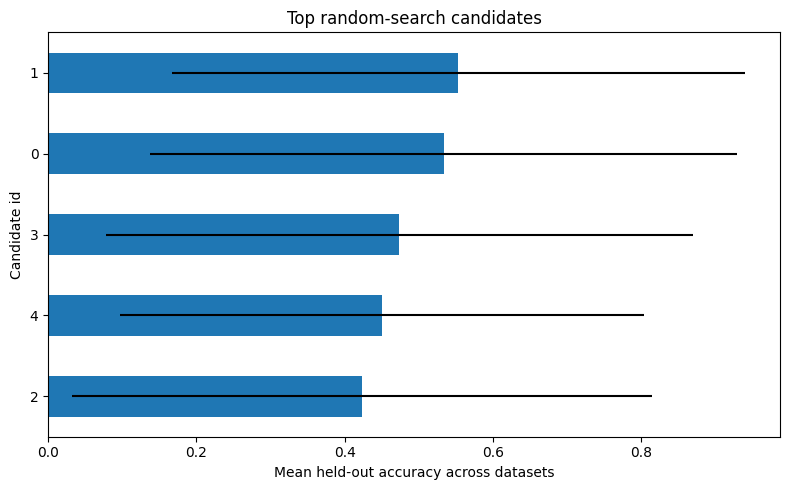

In [5]:
TOP_K = min(10, len(search_results))
top_results = search_results.head(TOP_K).copy()
display(
    top_results.style.format({
        'mean_accuracy': '{:.3f}',
        'std_dataset_accuracy': '{:.3f}',
        'mean_block_accuracy': '{:.3f}',
        'search_seconds': '{:.1f}',
    })
)

best_params = search_results.iloc[0][
    list(PARAMETER_RANGES.keys())
].to_dict()
display(pd.DataFrame([best_params]))

plot_data = top_results.sort_values('mean_accuracy')
ax = plot_data.plot(
    x='candidate_id',
    y='mean_accuracy',
    kind='barh',
    xerr='std_dataset_accuracy',
    legend=False,
    figsize=(8, 5),
)
ax.set_xlabel('Mean held-out accuracy across datasets')
ax.set_ylabel('Candidate id')
ax.set_title('Top random-search candidates')
fig = ax.get_figure()
fig.tight_layout()

In [6]:
best_candidate_id = int(search_results.iloc[0]['candidate_id'])
best_scores = block_results[
    block_results['candidate_id'] == best_candidate_id
]
best_by_dataset = (
    best_scores.groupby(['dataset_id', 'dataset'], as_index=False)
    .agg(
        mean_accuracy=('accuracy', 'mean'),
        std_accuracy=('accuracy', 'std'),
        n_repetitions=('accuracy', 'size'),
    )
    .sort_values('mean_accuracy', ascending=False)
)
display(best_by_dataset.style.format({
    'mean_accuracy': '{:.3f}',
    'std_accuracy': '{:.3f}',
}))

,dataset_id,dataset,mean_accuracy,std_accuracy,n_repetitions
0,3,kr-vs-kp,0.827,0.064,5
1,6,letter,0.280,0.069,5


## Marginalized performance by hyperparameter

These plots show the distribution of the dataset-averaged accuracy for every sampled value of each hyperparameter. Each point is one random-search candidate; grouping by one parameter marginalizes over the other sampled parameters.

In [7]:
marginal_rows = []
for parameter, values in PARAMETER_RANGES.items():
    for value in values:
        scores = search_results.loc[search_results[parameter] == value, 'mean_accuracy']
        marginal_rows.append({
            'parameter': parameter,
            'value': value,
            'n_candidates': scores.size,
            'q25_accuracy': scores.quantile(0.25) if scores.size else np.nan,
            'median_accuracy': scores.quantile(0.50) if scores.size else np.nan,
            'q75_accuracy': scores.quantile(0.75) if scores.size else np.nan,
        })

marginal_summary = pd.DataFrame(marginal_rows)
display(marginal_summary.style.format({
    'q25_accuracy': '{:.3f}',
    'median_accuracy': '{:.3f}',
    'q75_accuracy': '{:.3f}',
}))


,parameter,value,n_candidates,q25_accuracy,median_accuracy,q75_accuracy
0,n_estimators,30,1,0.423,0.423,0.423
1,n_estimators,100,0,nan,nan,nan
2,n_estimators,300,4,0.467,0.503,0.538
3,n_iterations,1,0,nan,nan,nan
4,n_iterations,2,1,0.533,0.533,0.533
5,n_iterations,3,3,0.437,0.450,0.502
6,n_iterations,4,1,0.473,0.473,0.473
7,dimension_mode,fixed,2,0.538,0.543,0.548
8,dimension_mode,expanding,3,0.437,0.450,0.462
9,normalization,none,1,0.423,0.423,0.423


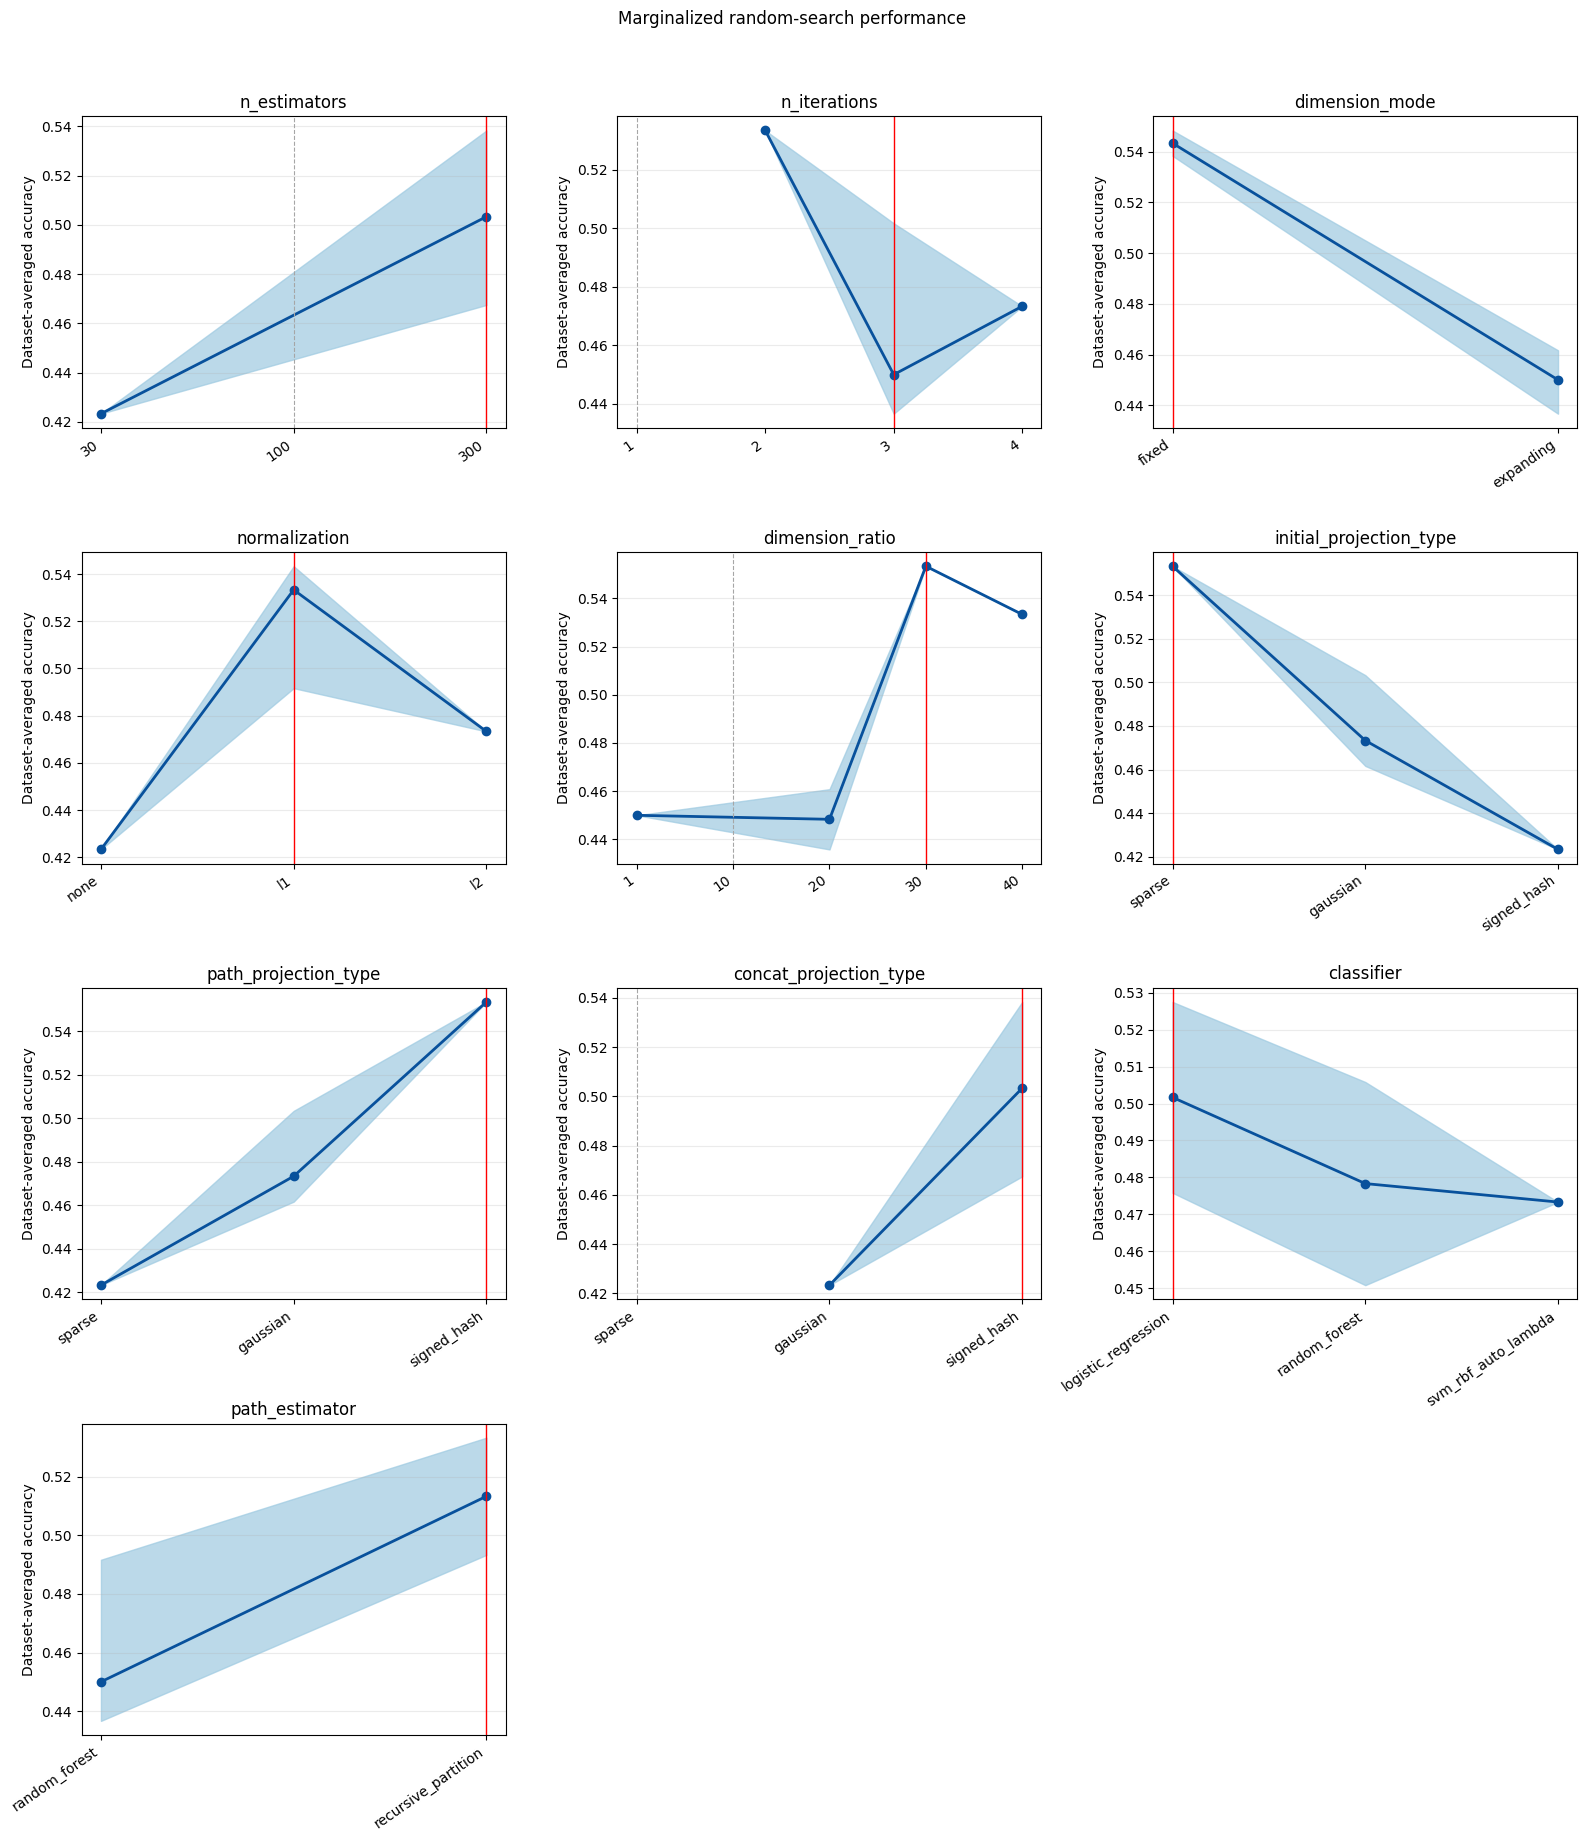

In [8]:

n_columns = 3
n_rows = int(np.ceil(len(PARAMETER_RANGES) / n_columns))
fig, axes = plt.subplots(
    n_rows, n_columns, figsize=(16, 4.5 * n_rows), squeeze=False
)
for axis, (parameter, allowed_values) in zip(axes.flat, PARAMETER_RANGES.items()):
    values = list(allowed_values)
    grouped = search_results[search_results[parameter].isin(values)].groupby(parameter)['mean_accuracy']
    quantiles = grouped.quantile([0.25, 0.50, 0.75]).unstack()
    quantiles = quantiles.reindex(values)
    positions = np.arange(len(values))
    observed = quantiles[0.50].notna().to_numpy()
    if observed.any():
        axis.fill_between(
            positions[observed], quantiles.loc[observed, 0.25],
            quantiles.loc[observed, 0.75],
            color='#9ecae1', alpha=0.7, label='25th–75th percentile'
        )
        axis.plot(
            positions[observed], quantiles.loc[observed, 0.50],
            marker='o', color='#08519c', linewidth=2, label='Median'
        )
    for position in positions[~observed]:
        axis.axvline(position, color='0.65', linestyle='--', linewidth=0.8)
    best_value = best_params[parameter]
    if best_value in values:
        axis.axvline(
            values.index(best_value), color='red', linestyle='-',
            linewidth=1.0, label='Best configuration'
        )
    axis.set_xticks(positions)
    axis.set_xticklabels([str(value) for value in values], rotation=35, ha='right')
    axis.set_title(parameter)
    axis.set_ylabel('Dataset-averaged accuracy')
    axis.grid(axis='y', alpha=0.25)

for axis in axes.flat[len(PARAMETER_RANGES):]:
    axis.set_visible(False)
fig.suptitle('Marginalized random-search performance', y=1.02)
fig.tight_layout()

The selected configuration maximizes the mean dataset-level accuracy on these evaluation blocks. For an unbiased final estimate, reserve additional datasets or repetitions as a validation set rather than reporting the same random-search score as final test performance.